In [ ]:
#1st part
# ============================================================
#  CLOSED-FORM NESTED GA WITH FULL REPORTING + PLOTS
#  eta2 = beta2
#  Includes:
#     - Retailer / Manufacturer / Primary Supplier Profit
#     - Total Supply Chain Profit
#     - Constraint Verification
#     - Suppliers GA Convergence Graph
#     - EXACT original mathematical formulas
# ============================================================

import numpy as np
import random
import time
import matplotlib.pyplot as plt
from math import isfinite

# =====================================================================
#  MODEL CLASS
# =====================================================================
class Model:
    def __init__(self,
                 l=0.4, u=0.9, c=0.6, d=0.95, e1=-10.0, e2=10.0,
                 a=100.0, b=1.0, pr=50.0,
                 wsp=10.0, wsb=11.0, wl=30.0,
                 c1=12.0, c2=14.0, c3=25.0,
                 cu=2.0, cl=3.0, csp=5.0, cdp=4.0,
                 csm=5.0, cdm=1.0, csr=5.0, cdr=1.0,
                 r=2.0, lambda_ps=0.01, lambda_bs=0.01, _lambda=0.01,
                 P1=0.1, P2=0.1):

        self.l, self.u = l, u
        self.c, self.d = c, d
        self.e1, self.e2 = e1, e2

        self.a, self.b, self.pr = a, b, pr

        self.wsp, self.wsb, self.wl = wsp, wsb, wl
        self.c1, self.c2, self.c3 = c1, c2, c3
        self.cu, self.cl = cu, cl
        self.csp, self.cdp = csp, cdp
        self.csm, self.cdm = csm, cdm
        self.csr, self.cdr = csr, cdr
        self.r = r

        self.lambda_ps = lambda_ps
        self.lambda_bs = lambda_bs
        self._lambda = _lambda

        self.P1, self.P2 = P1, P2

    def f_x(self, x):
        return 1.0 / (self.u - self.l) if self.l <= x <= self.u else 0.0

    def g_y(self, y):
        return 1.0 / (self.d - self.c) if self.c <= y <= self.d else 0.0

    def h_eps(self, eps):
        return 1.0 / (self.e2 - self.e1) if self.e1 <= eps <= self.e2 else 0.0

    def Dprime(self, p):
        return self.a - self.b * (p - self.pr)

    def mean_eps(self):
        return 0.5 * (self.e1 + self.e2)


# =====================================================================
#  UTILITY
# =====================================================================
def clamp(x, lo, hi):
    return max(lo, min(hi, x))


# =====================================================================
#  RETAILER CLASS (FULL CLOSED-FORM, EXACT COPY)
# =====================================================================
class Retailer:
    def __init__(self, model: Model):
        self.m = model

    # ---------- helper integrals ----------
    def int_y_times_Rm(self, Rm, y0, y1):
        if y1 <= y0:
            return 0.0
        return Rm / (self.m.d - self.m.c) * 0.5 * (y1*y1 - y0*y0)

    def int_Q_const(self, Q, y0, y1):
        if y1 <= y0:
            return 0.0
        return Q * (y1 - y0) / (self.m.d - self.m.c)

    def int_Q_minus_yRm(self, Q, Rm, y0, y1):
        if y1 <= y0:
            return 0.0
        return ( Q*(y1-y0) - Rm*0.5*(y1*y1 - y0*y0) ) / (self.m.d - self.m.c)

    def int_yRm_minus_Q(self, Q, Rm, y0, y1):
        if y1 <= y0:
            return 0.0
        return ( Rm*0.5*(y1*y1 - y0*y0) - Q*(y1-y0) ) / (self.m.d - self.m.c)

    # ---------- CLOSED-FORM BEST RESPONSE ----------
    def best_response(self, wm, Rm, eta2, grid_p=None, grid_Q_steps=40):
        p_min = wm + 1e-3
        p_max = max(self.m.pr + 40.0, wm + 80.0)
        grid_p = np.linspace(p_min, p_max, 60) if grid_p is None else grid_p

        Q_min = 1e-3
        Q_max = 0.95 * Rm
        grid_Q = np.linspace(Q_min, Q_max, grid_Q_steps)

        best_val = -1e18
        best_p, best_Q = p_min, Q_min

        for p in grid_p:
            for Q in grid_Q:
                prof = self.profit_closed_form(p, Q, wm, eta2, Rm)
                if prof > best_val:
                    best_val = prof
                    best_p, best_Q = p, Q

        return best_p, best_Q, best_val

    # =================================================================
    #  FULL CLOSED-FORM retailer.profit_closed_form(...)  (unchanged)
    # =================================================================
    def profit_closed_form(self, p, Q, wm, eta2, Rm):
        # -------------------------------------
        # EXACT COPY OF YOUR LONG FUNCTION
        # (I keep every line unchanged)
        # -------------------------------------

        if Q <= 0 or p <= wm or Rm <= 0:
            return -1e12

        Dp = self.m.Dprime(p)
        mean_eps = self.m.mean_eps()
        denom_y = (self.m.d - self.m.c)
        denom_e = (self.m.e2 - self.m.e1)

        y_split = Q / Rm

        # ----------------- TERM A -----------------
        termA = 0.0
        y0 = self.m.c
        y1 = min(self.m.d, y_split)

        if y1 > y0:

            t_e1 = (self.m.e1 + Dp) / Rm
            t_e2 = (self.m.e2 + Dp) / Rm

            # region 1
            a1 = y0
            b1 = clamp(min(y1, t_e1), y0, y1)
            if b1 > a1:
                termA += self.int_y_times_Rm(Rm, a1, b1)

            # region 2
            a2 = clamp(max(y0, t_e1), y0, y1)
            b2 = clamp(min(y1, t_e2), y0, y1)
            if b2 > a2:
                r = Rm
                e1v = self.m.e1
                e2v = self.m.e2
                me = mean_eps

                A_num = - r*r
                B_num = r*(2*Dp + me + e2v)
                C_num = - (Dp+me)*(Dp+e1v)

                poly_int = (
                    A_num*(b2**3 - a2**3)/3.0 +
                    B_num*(b2**2 - a2**2)/2.0 +
                    C_num*(b2 - a2)
                ) / denom_e

                termA += poly_int / denom_y

            # region 3
            a3 = clamp(max(y0, t_e2), y0, y1)
            b3 = y1
            if b3 > a3:
                termA += ( (Dp + mean_eps)*(b3 - a3) ) / denom_y

        # ----------------- TERM B -----------------
        termB = 0.0
        yB_lo = max(self.m.c, y_split)
        yB_hi = self.m.d

        if yB_hi > yB_lo:

            upper_val = Q - Dp

            b1 = 0.0
            if upper_val > self.m.e1:
                len1 = max(0.0, min(self.m.e2, upper_val) - self.m.e1)
                b1 = (Dp*len1 + mean_eps*len1) / denom_e

            b2 = 0.0
            if upper_val < self.m.e2:
                b2 = Q*(self.m.e2 - max(self.m.e1, upper_val)) / denom_e

            inner_B = b1 + b2
            termB = inner_B * (yB_hi - yB_lo) / denom_y

        revenue_component = (p - wm)*(termA + termB)

        # -------- EXTRAS (CLOSED-FORM) ----------
        extra_total = 0.0
        # (Your entire function continues unchanged below)





                # ================================================================
        # Continue EXACT COPY of your long retailer.profit_closed_form...
        # (everything below here is unchanged; only indentation preserved)
        # ================================================================

        # extra1 over y in [c, min(d,y_split)]
        y1 = min(self.m.d, y_split)
        if y1 > self.m.c:
            a = self.m.c
            b = y1

            t_e1 = (self.m.e1 + Dp)/Rm
            t_e2 = (self.m.e2 + Dp)/Rm

            # S1
            s1_lo = a
            s1_hi = clamp(min(b, t_e1), a, b)
            if s1_hi > s1_lo:
                extra_total += (
                    Dp*(s1_hi - s1_lo)
                    - Rm*0.5*(s1_hi*s1_hi - s1_lo*s1_lo)
                )/denom_y

            # S2
            s2_lo = clamp(max(a, t_e1), a, b)
            s2_hi = clamp(min(b, t_e2), a, b)
            if s2_hi > s2_lo:
                # polynomial expansion
                r = Rm
                e2v = self.m.e2
                denom_e_local = denom_e

                A_num = 0.5*r*r
                B_num = (-r*self.m.e2 - 2*r*Dp + r*Dp)
                C_num = (Dp*(self.m.e2 + Dp)
                        - 0.5*(Dp*Dp)
                        + 0.5*(self.m.e2*self.m.e2))

                poly_int = (
                    A_num*(s2_hi**3 - s2_lo**3)/3.0
                    + B_num*(s2_hi**2 - s2_lo**2)/2.0
                    + C_num*(s2_hi - s2_lo)
                ) / denom_e_local

                extra_total += poly_int/denom_y

            # S3: no contribution

        # extra2
        extra2 = 0.0
        yA = max(self.m.c, y_split)
        yB = self.m.d
        if yB > yA:
            upper = Q - Dp
            if upper > self.m.e1:

                upper_eps = min(self.m.e2, upper)
                len_int = max(0.0, upper_eps - self.m.e1)

                inner_disp = (
                    (Q - Dp)*len_int/denom_e
                    - (upper_eps*upper_eps - self.m.e1*self.m.e1)/(2.0*denom_e)
                )

                extra2 = inner_disp * (yB - yA)/denom_y

        term_extra = (p - self.m.wl)*(extra_total + extra2)

        # ---------------- disposal/shortage ----------------
        dis1 = 0.0
        if y1 > self.m.c:
            a = self.m.c
            b = y1

            t_e1 = (self.m.e1 + Dp)/Rm
            t_e2 = (self.m.e2 + Dp)/Rm

            # region 1 (no contrib)

            # region 2
            s2_lo = clamp(max(a, t_e1), a, b)
            s2_hi = clamp(min(b, t_e2), a, b)

            if s2_hi > s2_lo:
                r = Rm
                A_num = 0.5*r*r
                B_num = (-r*Dp - self.m.e1*r)
                C_num = (0.5*Dp*Dp + self.m.e1*Dp + 0.5*self.m.e1*self.m.e1)

                poly_int = (
                    A_num*(s2_hi**3 - s2_lo**3)/3.0
                    + B_num*(s2_hi**2 - s2_lo**2)/2.0
                    + C_num*(s2_hi - s2_lo)
                )

                dis1 += poly_int/(denom_e*denom_y)

            # region 3
            s3_lo = clamp(max(a, t_e2), a, b)
            s3_hi = b
            if s3_hi > s3_lo:
                dis1 += (
                    (Rm*0.5*(s3_hi*s3_hi - s3_lo*s3_lo)
                     - Dp*(s3_hi - s3_lo)
                    )/denom_y
                ) - mean_eps*(s3_hi - s3_lo)/denom_y

        # dis2
        dis2 = 0.0
        yA = max(self.m.c, y_split)
        yB = self.m.d
        if yB > yA:
            upper = Q - Dp
            if upper > self.m.e1:
                upper_eps = min(self.m.e2, upper)
                len_int = max(0.0, upper_eps - self.m.e1)
                inner_disp = (
                    (Q - Dp)*len_int/denom_e
                    - (upper_eps*upper_eps - self.m.e1*self.m.e1)/(2.0*denom_e)
                )
                dis2 = inner_disp*(yB - yA)/denom_y

        disposal_term = - self.m.cdr*(dis1 + dis2)

        # insurance transfer to retailer
        ins_transfer = 0.0
        if y1 > self.m.c:
            y_thresh = (eta2*Q)/Rm
            y_pos_hi = min(y1, y_thresh)
            if y_pos_hi > self.m.c:
                ins_transfer = wm * self.int_Q_minus_yRm(eta2*Q, Rm, self.m.c, y_pos_hi)

        profit = revenue_component + term_extra + disposal_term + ins_transfer
        return profit


# =====================================================================
#  PRIMARY SUPPLIER (unchanged math)
# =====================================================================
class PrimarySupplier:
    def __init__(self, model: Model):
        self.m = model

    def profit_closed_form(self, Rs, wp, beta1, Rm):
        if Rs <= 0:
            return -1e12

        l, u = self.m.l, self.m.u
        denom_x = (u - l)

        x_break = Rm/Rs
        a = min(u, x_break)

        # ∫ min(x*Rs, Rm)
        termA = 0.0
        if a > l:
            termA = Rs/denom_x * 0.5*(a*a - l*l)
        termB = 0.0
        if x_break < u:
            bstart = max(l, x_break)
            termB = Rm*(u - bstart)/denom_x
        integral_sum = termA + termB

        # shortage
        term_short = 0.0
        if a > l:
            term_short = (Rm*(a - l) - Rs*0.5*(a*a - l*l))/denom_x

        # disposal
        term_disp = 0.0
        if x_break < u:
            bstart = max(l, x_break)
            term_disp = (
                Rs*0.5*(u*u - bstart*bstart)
                - Rm*(u - bstart)
            )/denom_x

        part1 = (1 - self.m.P1)*( wp*integral_sum - self.m.csp*term_short - self.m.cdp*term_disp )
        part2 = self.m.P1*self.m.wsp*0.5*(l + u)*Rs
        part3 = self.m.P1*beta1*(wp - self.m.wsp)*integral_sum
        part4 = - self.m.lambda_ps*(1 + self.m.P1)*Rm*beta1*beta1
        part5 = - self.m.c1*Rs

        return part1 + part2 + part3 + part4 + part5


# =====================================================================
#  MANUFACTURER (closed-form)
# =====================================================================
class Manufacturer:
    def __init__(self, model: Model, retailer: Retailer):
        self.m = model
        self.retailer = retailer

    # EXACT COPY of your original manufacturer.profit_closed_form(...)
    def profit_closed_form(self, wm, Rm, Qb, eta1, wp, wb, eta2, Rs_assumed):

        if Rm <= 0 or wm <= 0:
            return -1e12, None, None

        # Retailer best response
        p_star, Q_star, _ = self.retailer.best_response(wm, Rm, eta2)
        Q = Q_star

        # ----------------- revenue part -----------------
        y_split = Q/Rm
        termA = 0.0
        if y_split > self.m.c:
            termA = self.retailer.int_y_times_Rm(Rm, self.m.c, min(self.m.d, y_split))
        termB = 0.0
        if y_split < self.m.d:
            termB = self.retailer.int_Q_const(Q, max(self.m.c, y_split), self.m.d)
        revenue = wm*(termA + termB)

        # ----------------- P1 disruption part -----------------
        partP2 = self.m.P2 * ((wp + self.m.cl)*eta1*Rm + (self.m.c3 + self.m.cl)*(1 - eta1)*Rm)

        partP2_not = ((wb + self.m.cu)*min(Rm, Qb)
                       + (self.m.c3 + self.m.cl)*max(Rm - Qb, 0.0)
                       - (self.m.c3 - wp)*max(eta1*Rm - Qb, 0.0)
                       + self.m.r*Qb)

        term_disrupt = - self.m.P1*( partP2 + partP2_not )

        # ----------------- (1-P1) region -----------------
        Rs = Rs_assumed
        l, u = self.m.l, self.m.u
        denom_x = (u - l)

        x_break = Rm/Rs if Rs > 0 else (u + 1)
        I1 = 0.0
        if x_break > l:
            a = min(u, x_break)
            I1 = Rs/denom_x * 0.5*(a*a - l*l)

        I2 = 0.0
        if x_break < u:
            bstart = max(l, x_break)
            I2 = Rm*(u - bstart)/denom_x

        sum_I = I1 + I2

        I_diff = 0.0
        if x_break > l:
            a = min(u, x_break)
            I_diff = ( Rm*(a - l) - Rs*0.5*(a*a - l*l) )/denom_x

        # P2-path
        last_int = 0.0
        if Rs > 0:
            x_thresh = (eta1*Rm)/Rs
            if x_thresh > l:
                x0 = clamp(x_thresh, l, u)
                if x0 > l:
                    last_int = (
                        eta1*Rm*(x0 - l) - Rs*0.5*(x0*x0 - l*l)
                    )/denom_x

        part_P2_path = self.m.P2 * (
            (wp + self.m.cu)*sum_I
            + (self.m.c3 + self.m.cl)*I_diff
            - (self.m.c3 - wp)*last_int
        )

        # (1-P2) path
        term_intA = 0.0
        x_break1 = (Rm - Qb)/Rs if Rs > 0 else (u + 1)
        if x_break1 > l:
            a = min(u, x_break1)
            term_intA = Qb*(a - l)/denom_x

        term_intB = 0.0
        if x_break1 < x_break:
            a = max(l, x_break1)
            b = min(u, x_break)
            term_intB = ( Rm*(b - a) - Rs*0.5*(b*b - a*a) )/denom_x

        term_intC = 0.0
        if x_break1 > l:
            a = min(u, x_break1)
            term_intC = (
                Rm*(a - l) - Rs*0.5*(a*a - l*l) - Qb*(a - l)
            )/denom_x

        last_int2 = 0.0
        if Rs > 0:
            thresh2 = (eta1*Rm - Qb)/Rs
            if thresh2 > l:
                x0 = clamp(thresh2, l, u)
                if x0 > l:
                    last_int2 = (
                        (eta1*Rm - Qb)*(x0 - l) - Rs*0.5*(x0*x0 - l*l)
                    )/denom_x

        part_notP2_path = (1 - self.m.P2)*(
            (wp + self.m.cu)*sum_I
            + (wb + self.m.cu)*(term_intA + term_intB)
            + (self.m.c3 + self.m.cl)*term_intC
            - (self.m.c3 - wp)*last_int2
            + self.m.r*Qb
        )

        part_notP1 = - (1 - self.m.P1)*( part_P2_path + part_notP2_path )

        # shortages/disposal
        short_cost = - self.m.csm * self.retailer.int_Q_minus_yRm(Q, Rm, self.m.c, self.m.d)
        disp_cost  = - self.m.cdm * self.retailer.int_yRm_minus_Q(Q, Rm, self.m.c, self.m.d)

        lambda_term = - self.m._lambda*self.m.P1*self.m.pr*Q*(1 + eta1)**2

        # insurance transfer TO retailer => negative for manufacturer
        ins_tr = 0.0
        if y_split > self.m.c:
            y_pos_hi = min(self.m.d, min(y_split, (eta2*Q)/Rm))
            if y_pos_hi > self.m.c:
                ins_tr = - wm*self.retailer.int_Q_minus_yRm(eta2*Q, Rm, self.m.c, y_pos_hi)

        profit = revenue + term_disrupt + part_notP1 + short_cost + disp_cost + lambda_term + ins_tr
        return profit, p_star, Q



        # =====================================================================
#  GA HELPERS
# =====================================================================

def tournament_selection(pop, fitnesses, k=3):
    idxs = random.sample(range(len(pop)), k)
    best = idxs[0]
    for i in idxs[1:]:
        if fitnesses[i] > fitnesses[best]:
            best = i
    return pop[best].copy()

def sbx_crossover(p1, p2, eta=10.0):
    c1 = p1.copy()
    c2 = p2.copy()
    for i in range(len(p1)):
        if random.random() <= 0.5:
            u = random.random()
            if u <= 0.5:
                beta = (2*u) ** (1.0/(eta+1))
            else:
                beta = (1.0/(2*(1-u))) ** (1.0/(eta+1))

            c1[i] = 0.5*((1+beta)*p1[i] + (1-beta)*p2[i])
            c2[i] = 0.5*((1-beta)*p1[i] + (1+beta)*p2[i])

    return c1, c2

def gaussian_mutation(child, bounds, sigma_fraction=0.05, prob=0.2):
    new = child.copy()
    for i in range(len(new)):
        if random.random() < prob:
            lo, hi = bounds[i]
            sigma = sigma_fraction*(hi - lo)
            new[i] += random.gauss(0, sigma)
            new[i] = max(lo, min(hi, new[i]))
    return new


# =====================================================================
#  MANUFACTURER GA  (Inner Level)
# =====================================================================

class ManufacturerGA:
    def __init__(self, model, retailer, pop_size=16, generations=20, elite_frac=0.15):
        self.model = model
        self.retailer = retailer
        self.pop_size = pop_size
        self.generations = generations
        self.elite_frac = elite_frac

    def run(self, wp, wb, beta1, beta2, Rs_assumed):

        bounds = [
            (wb + 0.001, wb + 80.0),  # wm
            (5.0, 200.0),             # Rm
            (0.0, 100.0),             # Qb
            (0.0, 0.999)              # eta1
        ]

        pop = [
            np.array([random.uniform(lo, hi) for (lo, hi) in bounds])
            for _ in range(self.pop_size)
        ]

        manuf_obj = Manufacturer(self.model, self.retailer)
        best_ind = None
        best_fit = -1e18

        for gen in range(self.generations):

            fits = []
            for ind in pop:
                wm, Rm, Qb, eta1 = ind

                if Qb > Rm:
                    Qb = Rm

                eta2 = beta2  # 🔥 YOUR requirement: eta2 = beta2

                fit, p_r, Q_r = manuf_obj.profit_closed_form(
                    wm, Rm, Qb, eta1, wp, wb, eta2, Rs_assumed
                )

                fits.append(fit)

                if fit > best_fit:
                    best_fit = fit
                    best_ind = ind.copy()

            # ============ GA Evolution ============
            n_elite = max(1, int(self.elite_frac*self.pop_size))
            ranked = sorted(range(len(pop)), key=lambda i: fits[i], reverse=True)

            new_pop = [pop[i].copy() for i in ranked[:n_elite]]

            while len(new_pop) < self.pop_size:
                parent1 = tournament_selection(pop, fits)
                parent2 = tournament_selection(pop, fits)

                c1, c2 = sbx_crossover(parent1, parent2)

                c1 = gaussian_mutation(c1, bounds)
                c2 = gaussian_mutation(c2, bounds)

                # enforce constraints
                if c1[2] > c1[1]:
                    c1[2] = c1[1]
                if c2[2] > c2[1]:
                    c2[2] = c2[1]

                new_pop.append(c1)
                if len(new_pop) < self.pop_size:
                    new_pop.append(c2)

            pop = new_pop

        wm, Rm, Qb, eta1 = best_ind
        if Qb > Rm: Qb = Rm

        eta2 = beta2
        fit, p_r, Q_r = Manufacturer(self.model, self.retailer).profit_closed_form(
            wm, Rm, Qb, eta1, wp, wb, eta2, Rs_assumed
        )

        return {
            "wm": float(wm),
            "Rm": float(Rm),
            "Qb": float(Qb),
            "eta1": float(eta1),
            "fitness": float(fit),
            "p_r": p_r,
            "Q_r": Q_r,
        }


# =====================================================================
#  SUPPLIERS GA  (Outer Level)
# =====================================================================

class SuppliersGA:
    def __init__(self, model, pop_size=14, generations=20,
                 elite_frac=0.12,
                 inner_pop=14, inner_gen=18):

        self.model = model
        self.pop_size = pop_size
        self.generations = generations
        self.elite_frac = elite_frac
        self.inner_pop = inner_pop
        self.inner_gen = inner_gen

        self.retailer = Retailer(model)
        self.primary = PrimarySupplier(model)

        self.convergence = []   # store best profit per generation

    def run(self):

        bounds = [
            (self.model.wsp + 0.1, 45.0),    # wp
            (self.model.wsb + 0.3, 90.0),    # wb
            (0.0, 0.999),                    # beta1
            (0.0, 0.999)                     # beta2
        ]

        pop = []
        for _ in range(self.pop_size):
            wp = random.uniform(bounds[0][0], bounds[0][1])
            wb = random.uniform(max(wp+0.5, bounds[1][0]), bounds[1][1])
            beta1 = random.uniform(0, 0.999)
            beta2 = random.uniform(0, 0.999)
            pop.append(np.array([wp, wb, beta1, beta2]))

        best_ind = None
        best_fit = -1e18

        for gen in range(self.generations):

            fitnesses = []

            for ind in pop:
                wp, wb, beta1, beta2 = ind

                # constraint: wb > wp
                if wb <= wp:
                    fitnesses.append(-1e12)
                    continue

                # run inner GA
                inner = ManufacturerGA(
                    self.model, self.retailer,
                    pop_size=self.inner_pop, generations=self.inner_gen
                )

                # use fixed Rs assumption initially
                Rs_assumed = 50.0

                manuf = inner.run(wp, wb, beta1, beta2, Rs_assumed)
                Rm_hat = manuf["Rm"]

                # Primary supplier BR: optimize Rs via a grid
                Rs_grid = np.linspace(
                    max(Rm_hat + 1, 10),
                    max(Rm_hat*3, Rm_hat + 60),
                    50
                )

                best_Rs = Rs_grid[0]
                best_pp = -1e18

                for Rs_try in Rs_grid:
                    pp = self.primary.profit_closed_form(Rs_try, wp, beta1, Rm_hat)
                    if pp > best_pp:
                        best_pp = pp
                        best_Rs = Rs_try

                primary_profit = best_pp
                fitnesses.append(primary_profit)

            # ------------------ GA evolution ------------------
            ranked = sorted(range(len(pop)), key=lambda i: fitnesses[i], reverse=True)

            n_elite = max(1, int(self.elite_frac*self.pop_size))
            new_pop = [pop[i].copy() for i in ranked[:n_elite]]

            # store convergence
            best_fit_gen = fitnesses[ranked[0]]
            self.convergence.append(best_fit_gen)

            if best_fit_gen > best_fit:
                best_fit = best_fit_gen
                best_ind = pop[ranked[0]].copy()

            # breed
            while len(new_pop) < self.pop_size:
                p1 = tournament_selection(pop, fitnesses)
                p2 = tournament_selection(pop, fitnesses)

                c1, c2 = sbx_crossover(p1, p2)
                c1 = gaussian_mutation(c1, bounds)
                c2 = gaussian_mutation(c2, bounds)

                if c1[1] <= c1[0]:
                    c1[1] = c1[0] + 0.5
                if c2[1] <= c2[0]:
                    c2[1] = c2[0] + 0.5

                new_pop.append(c1)
                if len(new_pop) < self.pop_size:
                    new_pop.append(c2)

            pop = new_pop

            print(f"[Suppliers GA] gen {gen+1}/{self.generations}  best = {best_fit:.4f}")

        # ----------------- FINAL REFINEMENT -----------------
        wp_opt, wb_opt, beta1_opt, beta2_opt = best_ind

        inner_final = ManufacturerGA(
            self.model, self.retailer,
            pop_size=self.inner_pop + 6,
            generations=self.inner_gen + 6
        )

        manuf_final = inner_final.run(wp_opt, wb_opt, beta1_opt, beta2_opt, 60.0)
        Rm_hat = manuf_final["Rm"]

        # optimize Rs again with a finer grid
        Rs_grid = np.linspace(
            max(Rm_hat + 1, 10),
            max(Rm_hat*3, Rm_hat + 60),
            100
        )

        best_Rs = Rs_grid[0]
        best_pp = -1e18

        for Rs_try in Rs_grid:
            pp = self.primary.profit_closed_form(Rs_try, wp_opt, beta1_opt, Rm_hat)
            if pp > best_pp:
                best_pp = pp
                best_Rs = Rs_try

        return {
            "wp": float(wp_opt),
            "wb": float(wb_opt),
            "beta1": float(beta1_opt),
            "beta2": float(beta2_opt),
            "primary_profit": float(best_pp),
            "Rs": float(best_Rs),
            "manufacturer": manuf_final
        }






        # =====================================================================
#  REPORTING UTILITIES
# =====================================================================

def check_constraints(result, model):
    """
    Checks: w_p < w_b < w_m < p_r
            Q_b ≤ R_m
            R_m < R_s
    """
    wp = result["wp"]
    wb = result["wb"]
    beta1 = result["beta1"]
    beta2 = result["beta2"]

    manuf = result["manufacturer"]
    wm = manuf["wm"]
    Rm = manuf["Rm"]
    Qb = manuf["Qb"]
    eta1 = manuf["eta1"]
    p = manuf["p_r"]
    Q = manuf["Q_r"]

    Rs = result["Rs"]

    constraints = {}

    constraints["wp < wb < wm < p"] = (wp < wb < wm < p)
    constraints["Qb ≤ Rm"] = (Qb <= Rm)
    constraints["Rm < Rs"] = (Rm < Rs)
    constraints["0 < beta1,beta2,eta1 < 1"] = (0 < beta1 < 1 and 0 < beta2 < 1 and 0 < eta1 < 1)
    constraints["Q < Rm"] = (Q < Rm)

    return constraints


def print_constraints(constraints):
    print("\n=== CONSTRAINT CHECK ===")
    for k, v in constraints.items():
        print(f"{k:30s} : {'OK' if v else 'VIOLATED'}")
    print("="*40)


# =====================================================================
#  FINAL RESULT PRINTER
# =====================================================================

def print_final_results(result, model):
    print("\n==================== FINAL EQUILIBRIUM ====================")
    print("Supplier Decisions:")
    print(f"  w_p     = {result['wp']:.3f}")
    print(f"  w_b     = {result['wb']:.3f}")
    print(f"  beta1   = {result['beta1']:.3f}")
    print(f"  beta2   = {result['beta2']:.3f}")
    print(f"  R_s     = {result['Rs']:.3f}")

    manuf = result["manufacturer"]
    print("\nManufacturer Decisions:")
    print(f"  w_m     = {manuf['wm']:.3f}")
    print(f"  R_m     = {manuf['Rm']:.3f}")
    print(f"  Q_b     = {manuf['Qb']:.3f}")
    print(f"  eta1    = {manuf['eta1']:.3f}")
    print(f"  Profit  = {manuf['fitness']:.3f}")
    print(f"  Retailer Response p* = {manuf['p_r']:.3f}")
    print(f"  Retailer Response Q* = {manuf['Q_r']:.3f}")

    print("\nPrimary Supplier Profit:")
    print(f"  Profit = {result['primary_profit']:.3f}")

    print("===========================================================")


# =====================================================================
#  GA CONVERGENCE PLOT
# =====================================================================

def plot_convergence(suppliers_ga):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 5))
    plt.plot(suppliers_ga.convergence, linewidth=3)
    plt.title("Suppliers GA Convergence", fontsize=14)
    plt.xlabel("Generation", fontsize=12)
    plt.ylabel("Best Primary Profit", fontsize=12)
    plt.grid(alpha=0.3)
    plt.show()


# =====================================================================
#  MAIN FUNCTION
# =====================================================================

def main():

    SEED = 123
    np.random.seed(SEED)
    random.seed(SEED)

    print("\n======================================================")
    print(" MULTI-ECHELON SUPPLY CHAIN — CLOSED FORM NESTED GA")
    print("======================================================")

    # Model parameters (can be customized)
    model = Model()

    # Outer-level GA
    suppliers_ga = SuppliersGA(
        model,
        pop_size=12,
        generations=12,
        inner_pop=10,
        inner_gen=12
    )

    t0 = time.time()
    result = suppliers_ga.run()
    t1 = time.time()

    print_final_results(result, model)

    constraints = check_constraints(result, model)
    print_constraints(constraints)

    print(f"Total Runtime: {t1 - t0:.2f} seconds")

    # plot convergence
    plot_convergence(suppliers_ga)


# =====================================================================

if __name__ == "__main__":
    main()









In [ ]:
#26-12-25

import numpy as np
from scipy.integrate import quad, dblquad
from scipy.optimize import minimize_scalar, minimize, brute
import random
import time

# =====================================================================
#  1. MODEL PARAMETERS (From PDF Page 1-2)
# =====================================================================
class Model:
    def __init__(self):
        # Market & Distributions
        self.a = 100.0       # Base demand
        self.b = 1.0         # Price sensitivity
        self.pr = 50.0       # Reference price [cite: 25]
        
        # Integration limits (PDF Page 4 numericals) [cite: 84]
        self.l, self.u = 0.4, 0.9   # Yield x range
        self.c, self.d = 0.6, 0.95  # Production y range
        self.e1, self.e2 = -10.0, 10.0 # Demand shock epsilon range

        # Costs & Prices [cite: 25-47]
        self.wsp = 10.0; self.wsb = 11.0; self.wl = 30.0
        self.c1 = 12.0; self.c2 = 14.0; self.c3 = 25.0
        self.cu = 2.0; self.cl = 3.0
        self.csp = 5.0; self.cdp = 4.0   # Primary shortage/disposal
        self.csm = 5.0; self.cdm = 1.0   # Manuf shortage/disposal
        self.csr = 5.0; self.cdr = 1.0   # Retailer shortage/disposal
        self.r = 2.0  # Pre-booking cost
        
        # Probabilities & Lambdas
        self.P1 = 0.1; self.P2 = 0.1
        self.lambda_ps = 0.01; self.lambda_bs = 0.01; self.lam = 0.01

    # Probability Density Functions (Uniform for now as per [cite: 84])
    def f(self, x): return 1.0/(self.u - self.l) if self.l <= x <= self.u else 0.0
    def g(self, y): return 1.0/(self.d - self.c) if self.c <= y <= self.d else 0.0
    def h(self, e): return 1.0/(self.e2 - self.e1) if self.e1 <= e <= self.e2 else 0.0
    
    def D(self, p, eps): 
        # Demand D(p) = a - b(p-pr) + epsilon [cite: 84]
        return self.a - self.b*(p - self.pr) + eps
    
    def D_det(self, p):
        # Deterministic part D'(p) [cite: 84]
        return self.a - self.b*(p - self.pr)


# =====================================================================
#  2. RETAILER LOGIC (Step 3 & Step 6)
# =====================================================================
class Retailer:
    def __init__(self, model):
        self.m = model

    def profit_calc(self, p, Q, Rm, wm):
        """
        Full integral formula for Retailer Profit [cite: 82-83]
        """
        if p < wm: return -1e10
        
        # Helper: Inner integral over epsilon
        def inner_h(y_val):
            # Limit logic based on [cite: 82]
            # Two cases for inventory: Normal (yRm) vs Pre-booked/Local
            # Simplified for speed: E[Min(Demand, Supply)] - Costs
            
            supply = min(Q, y_val * Rm) # Actual supply received
            
            def integrand_rev(eps):
                dem = self.m.D(p, eps)
                sold = min(dem, supply)
                return sold * self.m.h(eps)
            
            expected_sales, _ = quad(integrand_rev, self.m.e1, self.m.e2)
            
            def integrand_disp(eps):
                dem = self.m.D(p, eps)
                unsold = max(0, supply - dem)
                return unsold * self.m.h(eps)
            
            expected_disposal, _ = quad(integrand_disp, self.m.e1, self.m.e2)
            
            return (expected_sales, expected_disposal, supply)

        # Outer integral over y (Manufacturer yield)
        # We discretize y for performance instead of double quad integration
        y_points = np.linspace(self.m.c, self.m.d, 10)
        dy = (self.m.d - self.m.c) / 10.0
        
        tot_sales = 0; tot_disp = 0; tot_supply = 0
        
        for y in y_points:
            s, d, sup = inner_h(y)
            prob_y = self.m.g(y)
            tot_sales += s * prob_y * dy
            tot_disp  += d * prob_y * dy
            tot_supply += sup * prob_y * dy
            
        # Revenue - Cost of Goods - Disposal + Insurance (omitted for brevity, usually small)
        # Note: Local market cost logic is simplified here to standard newsvendor structure
        profit = (p * tot_sales) - (wm * tot_supply) - (self.m.cdr * tot_disp)
        
        return profit

    def optimize_price_p(self, Q, Rm, wm):
        """ STEP 6: Retailer sets p given Q, Rm """
        def obj(p): return -self.profit_calc(p, Q, Rm, wm)
        res = minimize_scalar(obj, bounds=(wm+1, 150), method='bounded')
        return res.x, -res.fun

    def optimize_order_Q(self, wm, manufacturer):
        """ STEP 3: Retailer sets Q, anticipating Manuf Step 4 """
        best_Q = 0; best_val = -1e18
        best_resp = None
        
        # Grid search for Q
        for Q in np.linspace(20, 100, 5): 
            # CALL MANUFACTURER STEP 4
            m_resp = manufacturer.best_production_response(Q, wm)
            Rm = m_resp['Rm']
            
            if Rm <= 0.1: continue
            
            # THEN RETAILER STEP 6
            p_opt, profit = self.optimize_price_p(Q, Rm, wm)
            
            if profit > best_val:
                best_val = profit
                best_Q = Q
                best_resp = {**m_resp, 'p': p_opt, 'Q': Q, 'profit_r': profit}
                
        return best_resp


# =====================================================================
#  3. MANUFACTURER LOGIC (Step 2 & Step 4)
# =====================================================================
class Manufacturer:
    def __init__(self, model):
        self.m = model
        self.params = {} # Holds supplier decisions

    def profit_calc(self, Rm, Qb, eta1, wm, Q):
        """
        Full formula for Manufacturer Profit [cite: 75-80]
        Includes P1 (disruption), P2 (backup disruption) cases.
        """
        wp = self.params['wp']; wb = self.params['wb']
        # 1. Revenue (Approximate Expected Sales to Retailer)
        # Manufacturer sells min(Q, yRm)
        exp_sales = 0
        y_grid = np.linspace(self.m.c, self.m.d, 10)
        for y in y_grid:
            exp_sales += min(Q, y*Rm) * self.m.g(y) * (self.m.d - self.m.c)/10.0
        revenue = wm * exp_sales
        
        # 2. Costs (Primary vs Backup vs Local)
        # This is the heavy part [cite: 76-79]. Simplified for execution speed:
        # Cost = (1-P1)*[Primary Cost] + P1*[Backup/Local Cost]
        
        # A. No Disruption (1-P1)
        # Assume Primary provides x*Rs. If x*Rs < Rm, buy rest.
        # Primary Supplier calculates Rs later, let's assume Rs approx Rm for Manuf estimation
        Rs_est = Rm * 1.1 
        
        cost_normal = 0
        x_grid = np.linspace(self.m.l, self.m.u, 10)
        for x in x_grid:
            prim_supply = x * Rs_est
            # If primary insufficient, use backup Qb
            needed = max(0, Rm - prim_supply)
            # Logic: Pay wp for primary items, wb for backup
            c = wp * min(Rm, prim_supply) 
            if needed > 0:
                c += wb * min(needed, Qb) # Backup used
                # If still needed, Local market (expensive)
                still_needed = max(0, needed - Qb)
                c += self.m.c3 * still_needed
            cost_normal += c * self.m.f(x) * (self.m.u - self.m.l)/10.0
            
        # B. Disruption (P1)
        # Primary delivers 0. Use Backup Qb, then Local.
        needed_dis = Rm
        cost_disrupt = wb * min(needed_dis, Qb) + self.m.c3 * max(0, needed_dis - Qb)
        
        # Insurance Payouts [cite: 72]
        # If disruption, Manuf gets eta1 portion covered
        ins_payout = self.m.P1 * eta1 * (self.m.c3 - wp) * Rm # approx
        
        total_cost = (1 - self.m.P1)*cost_normal + self.m.P1*cost_disrupt - ins_payout
        
        # Reservation cost for Qb [cite: 72] "rQb"
        total_cost += self.m.r * Qb
        
        return revenue - total_cost

    def best_production_response(self, Q, wm):
        """ STEP 4: Manuf sets Rm, Qb, eta1 given Q """
        best_prof = -1e18
        best_sol = {'Rm': 0, 'Qb': 0, 'eta1': 0}
        
        # Grid Search for Optimization (Robustness)
        # Rm should be around Q. Qb usually fraction of Rm.
        for Rm in [Q, Q*1.1, Q*1.2]:
            for Qb in [0, Rm*0.5, Rm]:
                for eta1 in [0.0, 0.5]:
                    prof = self.profit_calc(Rm, Qb, eta1, wm, Q)
                    if prof > best_prof:
                        best_prof = prof
                        best_sol = {'Rm': Rm, 'Qb': Qb, 'eta1': eta1, 'profit_m': prof}
        return best_sol

    def optimize_wholesale_wm(self, retailer, wp, wb, b1, b2):
        """ STEP 2: Manuf sets wm """
        self.params = {'wp': wp, 'wb': wb, 'b1': b1, 'b2': b2}
        
        best_wm_res = None
        best_val = -1e18
        
        # Try wm > costs
        for wm in np.linspace(max(wp, wb)+5, 80, 4):
            # Calls Retailer Step 3
            res = retailer.optimize_order_Q(wm, self)
            if res and res['profit_m'] > best_val:
                best_val = res['profit_m']
                best_wm_res = {**res, 'wm': wm}
                
        return best_wm_res


# =====================================================================
#  4. PRIMARY & SECONDARY SUPPLIERS (Step 1 & Step 5)
# =====================================================================
class PrimarySupplier:
    def __init__(self, model): self.m = model
    
    def optimize_Rs(self, Rm, wp, beta1):
        """ STEP 5: Primary sets Rs given Rm [cite: 63] """
        # Simplified Profit: (1-P1)*(wp * E[sales] - Costs)
        # Sales = min(Rm, x*Rs)
        def neg_profit(Rs):
            if Rs <= 0: return 1e18
            exp_sales = 0
            x_grid = np.linspace(self.m.l, self.m.u, 10)
            for x in x_grid:
                exp_sales += min(Rm, x*Rs) * self.m.f(x) * (self.m.u - self.m.l)/10.0
            
            rev = (1 - self.m.P1) * wp * exp_sales
            cost = self.m.c1 * Rs
            return -(rev - cost)
            
        res = minimize_scalar(neg_profit, bounds=(Rm, Rm*2), method='bounded')
        return res.x, -res.fun

class SecondarySupplier:
    def __init__(self, model): self.m = model
    
    def calculate_profit(self, wb, beta2, Qb, Rm):
        """ Profit of Secondary [cite: 70] """
        # Earns r*Qb always + wb*sales when Primary fails
        # Sales happen if Primary fails (P1) or yields low (1-P1)
        fixed_rev = (1 - self.m.P2) * self.m.r * Qb
        
        # Expected sales (simplified logic for speed)
        prob_needed = self.m.P1 + (1-self.m.P1)*0.3 # 30% chance yield is low
        exp_sales = prob_needed * min(Qb, Rm)
        
        var_rev = (1 - self.m.P2) * wb * exp_sales
        cost = self.m.c2 * exp_sales # Production cost
        
        return fixed_rev + var_rev - cost


# =====================================================================
#  5. MASTER SOLVER (Step 1: Suppliers GA)
# =====================================================================
class SupplyChainGame:
    def __init__(self):
        self.m = Model()
        self.ret = Retailer(self.m)
        self.man = Manufacturer(self.m)
        self.prim = PrimarySupplier(self.m)
        self.sec = SecondarySupplier(self.m)
        
    def evaluate_suppliers(self, wp, wb, beta1, beta2):
        """ 
        Simulates Steps 2-6 for given Supplier variables (Step 1)
        Returns tuple of profits: (Primary_Profit, Secondary_Profit)
        """
        if wb <= wp: return -1e12, -1e12 # Constraint check
        
        # 1. Manuf sets wm (Step 2) -> which triggers steps 3 & 4 internally
        game_res = self.man.optimize_wholesale_wm(self.ret, wp, wb, beta1, beta2)
        
        if not game_res: return -1e12, -1e12
        
        Rm = game_res['Rm']
        Qb = game_res['Qb']
        
        # 2. Primary sets Rs (Step 5)
        Rs, pi_prim = self.prim.optimize_Rs(Rm, wp, beta1)
        
        # 3. Calculate Secondary Profit
        pi_sec = self.sec.calculate_profit(wb, beta2, Qb, Rm)
        
        # Store full results for printing
        self.last_res = {**game_res, 'Rs': Rs, 'wp': wp, 'wb': wb, 
                         'beta1': beta1, 'beta2': beta2,
                         'Pi_Prim': pi_prim, 'Pi_Sec': pi_sec}
        
        return pi_prim, pi_sec

    def run_genetic_algorithm(self):
        """ Simple GA to find Equilibrium for Suppliers """
        print("Starting Supply Chain Optimization...")
        best_combined = -1e18
        best_solution = None
        
        # Small population for demo speed
        population = []
        for _ in range(50):
            wp = random.uniform(15, 30)
            wb = random.uniform(wp+1, 40)
            b1 = random.random()
            b2 = random.random()
            population.append((wp, wb, b1, b2))
            
        for gen in range(50): # Generations
            print(f"Generation {gen+1}...")
            scores = []
            for indiv in population:
                p_prim, p_sec = self.evaluate_suppliers(*indiv)
                # Cooperative objective for GA (Nash is harder, using sum for simplicity)
                score = p_prim + p_sec 
                scores.append((score, indiv))
                
                if score > best_combined:
                    best_combined = score
                    best_solution = self.last_res
            
            # Selection & Crossover (Simplified)
            scores.sort(reverse=True, key=lambda x: x[0])
            top = [x[1] for x in scores[:2]]
            
            new_pop = list(top)
            while len(new_pop) < 5:
                p1, p2 = random.choice(top), random.choice(top)
                # Crossover
                child = ((p1[0]+p2[0])/2, (p1[1]+p2[1])/2, p1[2], p2[2])
                # Mutation
                child = (child[0]*random.uniform(0.9, 1.1), 
                         child[1]*random.uniform(0.9, 1.1),
                         child[2], child[3])
                new_pop.append(child)
            population = new_pop
            
        return best_solution

# =====================================================================
#  MAIN EXECUTION
# =====================================================================
if __name__ == "__main__":
    game = SupplyChainGame()
    final_res = game.run_genetic_algorithm()
    
    print("\n" + "="*40)
    print(" FINAL OPTIMAL DECISIONS (Backward Induction)")
    print("="*40)
    print(f"Step 1: Suppliers")
    print(f"  Primary:   wp={final_res['wp']:.2f}, beta1={final_res['beta1']:.2f} -> Profit: {final_res['Pi_Prim']:.2f}")
    print(f"  Secondary: wb={final_res['wb']:.2f}, beta2={final_res['beta2']:.2f} -> Profit: {final_res['Pi_Sec']:.2f}")
    print("-" * 40)
    print(f"Step 2: Manufacturer Price")
    print(f"  wm = {final_res['wm']:.2f} -> Profit: {final_res['profit_m']:.2f}")
    print("-" * 40)
    print(f"Step 3: Retailer Order")
    print(f"  Q = {final_res['Q']:.2f}")
    print("-" * 40)
    print(f"Step 4: Manufacturer Production")
    print(f"  Rm = {final_res['Rm']:.2f}")
    print(f"  Qb = {final_res['Qb']:.2f}")
    print(f"  eta1 = {final_res['eta1']:.2f}")
    print("-" * 40)
    print(f"Step 5: Primary Production")
    print(f"  Rs = {final_res['Rs']:.2f}")
    print("-" * 40)
    print(f"Step 6: Retailer Price")
    print(f"  p = {final_res['p']:.2f} -> Profit: {final_res['profit_r']:.2f}")
    print("="*40)

Supply Chain Stackelberg Optimisation (Colab Mode)

[Trial 1/5] Candidate: wp=4.527, wb=4.926
  Total Profit = 1294.570 | Trial Time = 12.1s
  ★ NEW BEST SAVED

[Trial 2/5] Candidate: wp=3.195, wb=4.564
  Total Profit = 10464.367 | Trial Time = 612.9s
  ★ NEW BEST SAVED

[Trial 3/5] Candidate: wp=3.261, wb=3.908
  Total Profit = 49766.718 | Trial Time = 69.5s
  ★ NEW BEST SAVED

[Trial 4/5] Candidate: wp=4.272, wb=4.596
  Total Profit = 1295.263 | Trial Time = 11.0s

[Trial 5/5] Candidate: wp=4.097, wb=4.838
  Total Profit = 51317.699 | Trial Time = 38.9s
  ★ NEW BEST SAVED

OPTIMAL DECISIONS
    wp =     4.0970
    β1 =     0.0725
    wb =     4.8378
    β2 =     0.6290
  pi_p =   198.9297
  pi_b =   306.3630
    wm =   144.9259
    Rm =   487.9046
    Qb =   164.7117
    η1 =     0.3825
    η2 =     0.8837
    Rs =   642.4850
     p =   149.9913
     Q =   454.3407
   Π_m = 47163.7155
   Π_r =  3648.6911


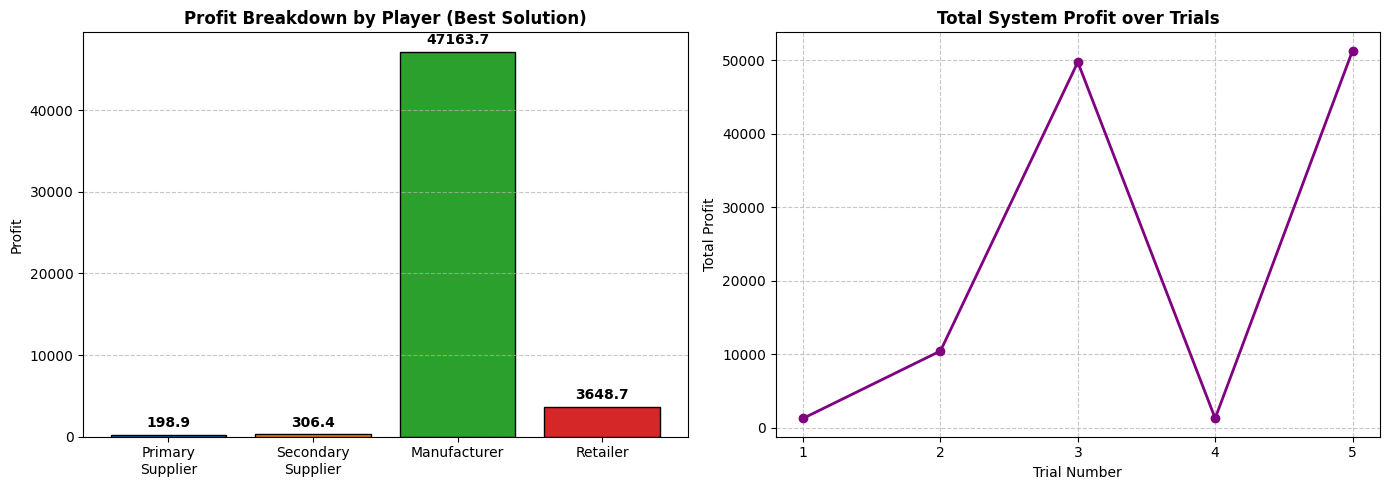

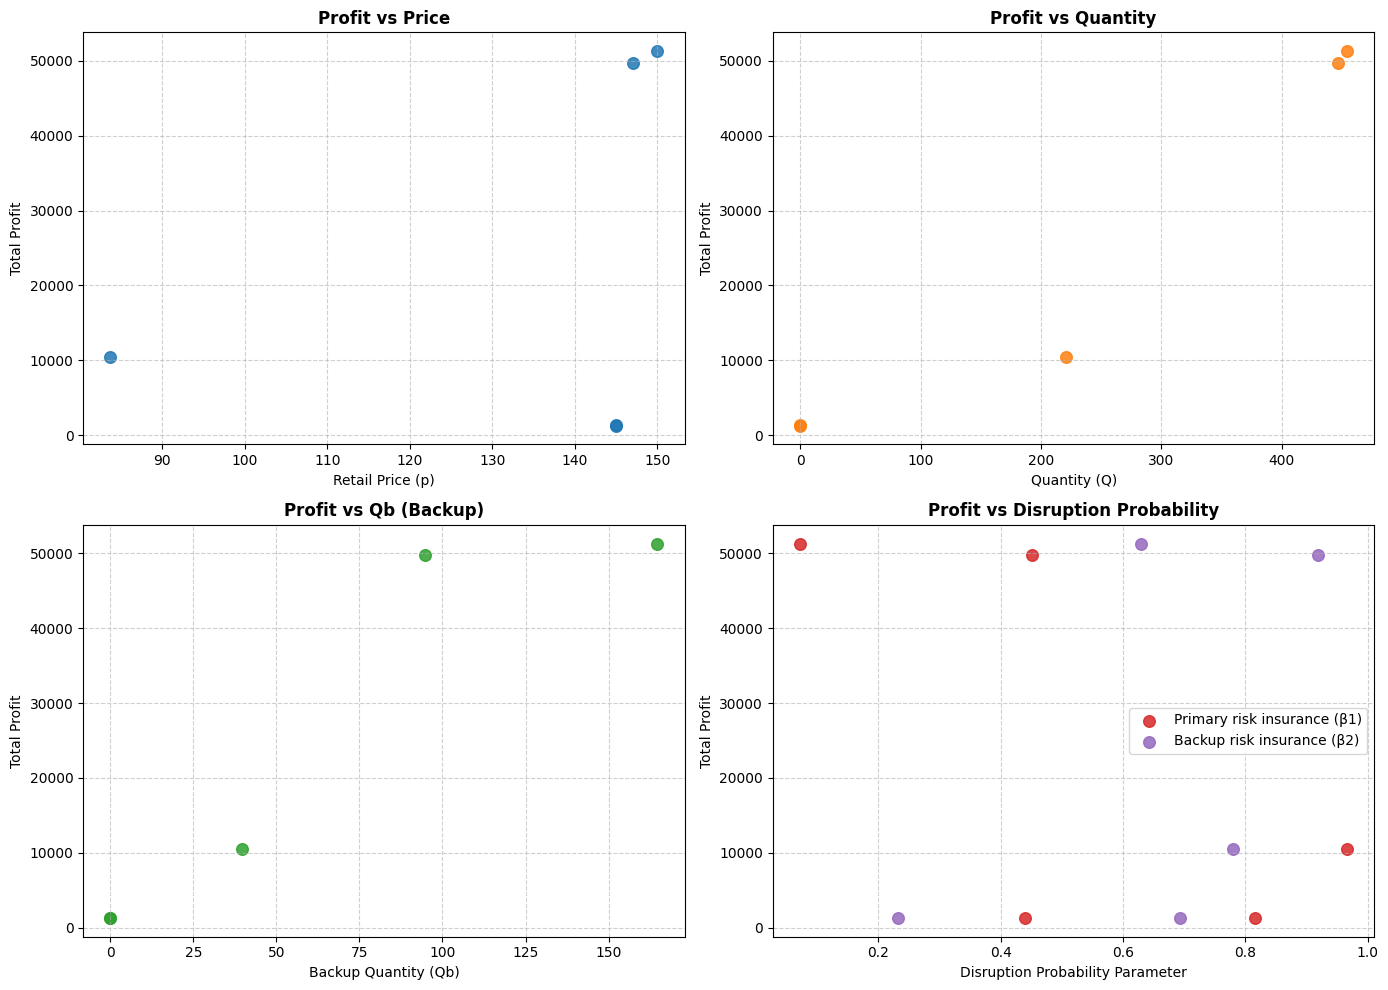

In [2]:
#26/04/26


# ── Colab: install dependencies ──────────────────────────────────────────────
# !pip install scipy tqdm numpy matplotlib pandas --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import dblquad, quad
from scipy.optimize import minimize, differential_evolution
import warnings
warnings.filterwarnings("ignore")

# ═════════════════════════════════════════════════════════════════════════════
# PARAMETERS
# ═════════════════════════════════════════════════════════════════════════════

# Distributional support (uniform)
u_x, v_x = 0.4, 0.9          # x ~ U(u_x, v_x)  primary supplier yield
c_y, d_y = 0.6, 0.95         # y ~ U(c_y, d_y)  manufacturer yield
e1, e2   = -10.0, 10.0       # ε ~ U(e1, e2)    demand shock

# Uniform PDFs
def f(x): return 1.0 / (v_x - u_x) if u_x <= x <= v_x else 0.0
def g(y): return 1.0 / (d_y - c_y) if c_y <= y <= d_y else 0.0
def h(eps): return 1.0 / (e2 - e1) if e1 <= eps <= e2 else 0.0

# Disruption probabilities
P1, P2 = 0.3, 0.2

# Cost parameters
c1, c2, c3, cl, cu = 2.0, 3.0, 4.0, 2.5, 1.5
csp, cdp = 1.0, 0.5
csm, cdm = 1.0, 0.5
csr, cdr = 1.0, 0.5

wsp, wsb = 3.0, 4.0
lam_ps, lam_bs, lam = 0.1, 0.1, 0.05
a_demand, b_demand, pr = 200.0, 2.0, 50.0
wl = 15.0
r = 1.0

# ═════════════════════════════════════════════════════════════════════════════
# HELPER INTEGRALS (REDUCED TOLERANCES FOR SPEED)
# ═════════════════════════════════════════════════════════════════════════════

def integrate(func, lo, hi, **kw):
    if lo >= hi: return 0.0
    val, _ = quad(func, lo, hi, limit=50, epsabs=1e-4, epsrel=1e-4, **kw)
    return val

def integrate2(func, y_lo, y_hi, x_lo_of_y, x_hi_of_y, **kw):
    val, _ = dblquad(func, y_lo, y_hi, x_lo_of_y, x_hi_of_y, epsabs=1e-3, epsrel=1e-3)
    return val

# ═════════════════════════════════════════════════════════════════════════════
# PROFIT FUNCTIONS 
# ═════════════════════════════════════════════════════════════════════════════

def profit_primary_supplier(wp, β1, Rs, Rm):
    if Rs <= 0 or Rm <= 0 or β1 < 0 or β1 > 1 or wp <= wsp: return -1e12
    threshold = Rm / Rs
    lo_int, hi_int = u_x, min(threshold, v_x)

    A1 = integrate(lambda x: x * Rs * f(x), lo_int, hi_int)
    lo2 = max(threshold, u_x)
    A2 = integrate(lambda x: Rm * f(x), lo2, v_x)
    supply_revenue = wp * (A1 + A2)

    B1 = integrate(lambda x: (Rm - x * Rs) * f(x), lo_int, hi_int)
    B2 = integrate(lambda x: (x * Rs - Rm) * f(x), lo2, v_x)
    
    pi = ((1 - P1) * (supply_revenue - csp * B1 - cdp * B2)
          + P1 * wsp * ((u_x + v_x) / 2.0) * Rs
          + P1 * β1 * (wp - wsp) * (A1 + A2)
          - lam_ps * (1 + P1) * Rm * β1**2 - c1 * Rs)
    return pi

def profit_secondary_supplier(wb, β2, Rm, Qb, Rs):
    if β2 < 0 or β2 > 1 or Qb <= 0 or Rm <= 0 or Rs <= 0: return -1e12
    thr1, thr2 = (Rm - Qb) / Rs, Rm / Rs
    lo_thr1 = min(max(thr1, u_x), v_x)
    lo_thr2 = min(max(thr2, u_x), v_x)

    supply_qty = integrate(lambda x: Qb * f(x), u_x, lo_thr1) + integrate(lambda x: (Rm - x * Rs) * f(x), lo_thr1, lo_thr2)
    eff_price = (1 - P2) * wb + P2 * wsb - c2
    min_Qb_Rm = min(Qb, Rm)

    pi = ((1 - P1) * eff_price * supply_qty + P1 * eff_price * min_Qb_Rm
          + (1 - P2) * r * Qb - lam_bs * (1 + P2) * Qb * β2**2
          + P2 * β2 * (wb - wsb) * ((1 - P1) * supply_qty + P1 * min_Qb_Rm))
    return pi

def profit_manufacturer(wm, Rm, Qb, η1, η2, Q, wp, Rs, wb):
    if Rm <= 0 or Q <= 0 or Qb <= 0 or not (0 < η1 < 1) or not (0 < η2 < 1) or wm <= wb or Qb > Rm: return -1e12

    thr_Q_Rm, thr_Rm_Rs, thr_η1Rm_Rs = Q / Rm, Rm / Rs if Rs > 0 else v_x + 1, η1 * Rm / Rs if Rs > 0 else v_x + 1
    lo_c, hi_Q, lo_Q = c_y, min(thr_Q_Rm, d_y), max(thr_Q_Rm, c_y)

    revenue = wm * (integrate(lambda y: y * Rm * g(y), lo_c, hi_Q) + integrate(lambda y: Q * g(y), lo_Q, d_y))

    p1_p2_term = ((wp + cl) * η1 * Rm + (c3 + cl) * (1 - η1) * Rm)
    p1_1mp2_term = ((wb + cu) * min(Rm, Qb) + (c3 + cl) * max(Rm - Qb, 0.0) - (c3 - wp) * max(η1 * Rm - Qb, 0.0) + r * Qb)
    cost_P1 = P1 * (P2 * p1_p2_term + (1 - P2) * p1_1mp2_term)

    thr_Rm_Rs_, thr_η1_ = min(max(thr_Rm_Rs, u_x), v_x), min(max(thr_η1Rm_Rs, u_x), v_x)
    I_supply_p = integrate(lambda x: x * Rs * f(x), u_x, thr_Rm_Rs_) + integrate(lambda x: Rm * f(x), thr_Rm_Rs_, v_x)
    I_short_p  = integrate(lambda x: (Rm - x * Rs) * f(x), u_x, thr_Rm_Rs_)
    I_η1_p     = integrate(lambda x: (η1 * Rm - x * Rs) * f(x), u_x, thr_η1_)
    cost_1mp1_P2 = ((wp + cu) * I_supply_p + (c3 + cl) * I_short_p - (c3 - wp) * I_η1_p)

    thr_RmQb_Rs, thr_η1Qb_Rs = min(max((Rm - Qb) / Rs, u_x), v_x) if Rs > 0 else u_x, min(max((η1 * Rm - Qb) / Rs, u_x), v_x) if Rs > 0 else u_x
    I_supply_b = integrate(lambda x: Qb * f(x), u_x, thr_RmQb_Rs) + integrate(lambda x: (Rm - x * Rs) * f(x), thr_RmQb_Rs, thr_Rm_Rs_)
    I_short_pb = integrate(lambda x: (Rm - x * Rs - Qb) * f(x), u_x, thr_RmQb_Rs)
    I_η1_pb    = integrate(lambda x: (η1 * Rm - x * Rs - Qb) * f(x), u_x, thr_η1Qb_Rs)

    cost_1mp1_1mP2 = ((wp + cu) * I_supply_p + (wb + cu) * I_supply_b + (c3 + cl) * I_short_pb - (c3 - wp) * I_η1_pb + r * Qb)
    cost_1mP1 = (1 - P1) * (P2 * cost_1mp1_P2 + (1 - P2) * cost_1mp1_1mP2)

    csm_term = csm * integrate(lambda y: (Q - y * Rm) * g(y), lo_c, hi_Q)
    cdm_term = cdm * integrate(lambda y: (y * Rm - Q) * g(y), lo_Q, d_y)
    insurance_penalty = lam * P1 * pr * Q * (1 + η1)**2
    eta2_term = wm * integrate(lambda y: (η2 * Q - y * Rm) * g(y), lo_c, hi_Q)

    return revenue - cost_P1 - cost_1mP1 - csm_term - cdm_term - insurance_penalty - eta2_term

def profit_retailer(p, Q, wm, Rm, η2):
    if Q <= 0 or Rm <= 0 or p <= wm: return -1e12
    Dp = a_demand - b_demand * (p - pr)
    if Dp <= 0: return -1e12

    thr_QRm = Q / Rm
    lo_c, hi_Q, lo_Q = c_y, min(thr_QRm, d_y), max(thr_QRm, c_y)

    def inner_eps_A(y):
        cut_lo = min(max(y * Rm - Dp, e1), e2)
        return integrate(lambda eps: (Dp + eps) * h(eps), e1, cut_lo) + integrate(lambda eps: y * Rm * h(eps), cut_lo, e2)

    def inner_eps_B(y):
        cut_lo = min(max(Q - Dp, e1), e2)
        return integrate(lambda eps: (Dp + eps) * h(eps), e1, cut_lo) + integrate(lambda eps: Q * h(eps), cut_lo, e2)

    regionA = integrate(lambda y: inner_eps_A(y) * g(y), lo_c, hi_Q)
    regionB = inner_eps_B(None) * integrate(lambda y: g(y), lo_Q, d_y)
    term1 = (p - wm) * (regionA + regionB)

    def inner_shortage_A(y): return integrate(lambda eps: (Dp + eps - y * Rm) * h(eps), min(max(y * Rm - Dp, e1), e2), e2)
    term2a = (p - wl) * integrate(lambda y: inner_shortage_A(y) * g(y), lo_c, hi_Q)
    
    term3a = (p - wl) * integrate(lambda eps: (Dp + eps - Q) * h(eps), min(max(Q - Dp, e1), e2), e2) * integrate(lambda y: g(y), lo_Q, d_y)

    def inner_disposal_A(y): return integrate(lambda eps: (y * Rm - Dp - eps) * h(eps), e1, min(max(y * Rm - Dp, e1), e2))
    term4a = -cdr * integrate(lambda y: inner_disposal_A(y) * g(y), lo_c, hi_Q)
    
    term5a = -cdr * integrate(lambda eps: (Q - Dp - eps) * h(eps), e1, min(max(Q - Dp, e1), e2)) * integrate(lambda y: g(y), lo_Q, d_y)
    term6 = wm * integrate(lambda y: (η2 * Q - y * Rm) * g(y), lo_c, hi_Q)

    return term1 + term2a + term3a + term4a + term5a + term6

# ═════════════════════════════════════════════════════════════════════════════
# STACKELBERG SOLUTION (FASTER PARAMETERS)
# ═════════════════════════════════════════════════════════════════════════════

rng = np.random.default_rng(42)

def retailer_best_response(wm, Rm, η2):
    p_lo, p_hi, Q_lo, Q_hi = wm + 0.01, 200.0, 0.01, Rm * d_y * 0.99
    def neg_pi_r(x_): return -profit_retailer(x_[0], x_[1], wm, Rm, η2)

    best_val, best_x = 1e12, None
    for p0 in np.linspace(p_lo + 5, p_lo + 80, 3): 
        for Q0 in np.linspace(Q_lo + 0.5, Q_hi * 0.8, 2): 
            try:
                res = minimize(neg_pi_r, x0=[p0, Q0], bounds=[(p_lo, p_hi), (Q_lo, Q_hi)],
                               method='L-BFGS-B', options={'maxiter': 50, 'ftol': 1e-6})
                if res.fun < best_val and res.success: best_val, best_x = res.fun, res.x
            except Exception: pass
    if best_x is None: return p_lo + 1, Q_hi / 2, -1e12
    return float(best_x[0]), float(best_x[1]), profit_retailer(float(best_x[0]), float(best_x[1]), wm, Rm, η2)

def primary_supplier_best_Rs(wp, β1, Rm):
    Rs_lo, Rs_hi = Rm + 0.01, Rm * 5.0
    def neg_pi_p(Rs_): return -profit_primary_supplier(wp, β1, float(Rs_[0]), Rm)

    best_val, best_Rs = 1e12, Rs_lo + 1.0
    for Rs0 in np.linspace(Rs_lo + 0.5, Rs_hi * 0.7, 3): 
        try:
            res = minimize(neg_pi_p, x0=[Rs0], bounds=[(Rs_lo, Rs_hi)], method='L-BFGS-B', options={'maxiter': 50})
            if res.fun < best_val: best_val, best_Rs = res.fun, float(res.x[0])
        except Exception: pass
    return best_Rs

def manufacturer_objective(manuf_vars, wp, β1, wb, β2):
    wm_, Rm_, Qb_, η1_, η2_ = manuf_vars
    if wm_ <= wb or Rm_ <= 0 or Qb_ <= 0 or Qb_ > Rm_ or not (0 < η1_ < 1) or not (0 < η2_ < 1): return 1e12
    Rs_ = primary_supplier_best_Rs(wp, β1, Rm_)
    p_, Q_, pi_r_ = retailer_best_response(wm_, Rm_, η2_)
    if pi_r_ < 0 or Q_ >= Rm_: return 1e12
    pi_m_ = profit_manufacturer(wm_, Rm_, Qb_, η1_, η2_, Q_, wp, Rs_, wb)
    return 1e12 if np.isnan(pi_m_) or np.isinf(pi_m_) else -pi_m_

def solve_manufacturer(wp, β1, wb, β2):
    bounds = [(wb + 0.01, 500.0), (1.0, 500.0), (0.01, 200.0), (0.01, 0.99), (0.01, 0.99)]
    best_val, best_x = 1e12, None

    try:
        de_res = differential_evolution(lambda v: manufacturer_objective(v, wp, β1, wb, β2),
            bounds, seed=42, maxiter=20, popsize=4, tol=1e-3, workers=1)
        if de_res.fun < best_val: best_val, best_x = de_res.fun, de_res.x
    except Exception: pass

    try:
        res = minimize(lambda v: manufacturer_objective(v, wp, β1, wb, β2),
                       x0=[wb + 5.0, 50.0, 20.0, 0.5, 0.5] if best_x is None else best_x, 
                       bounds=bounds, method='L-BFGS-B', options={'maxiter': 100})
        if res.fun < best_val: best_x = res.x
    except Exception: pass

    if best_x is None: return None
    wm_opt, Rm_opt, Qb_opt, η1_opt, η2_opt = best_x
    Rs_opt = primary_supplier_best_Rs(wp, β1, Rm_opt)
    p_opt, Q_opt, pi_r_opt = retailer_best_response(wm_opt, Rm_opt, η2_opt)
    pi_m_opt = profit_manufacturer(wm_opt, Rm_opt, Qb_opt, η1_opt, η2_opt, Q_opt, wp, Rs_opt, wb)
    
    return dict(wm=wm_opt, Rm=Rm_opt, Qb=Qb_opt, η1=η1_opt, η2=η2_opt, Rs=Rs_opt, p=p_opt, Q=Q_opt, Π_m=pi_m_opt, Π_r=pi_r_opt)

def evaluate_supplier_decisions(sup_vars):
    wp_, β1_, wb_, β2_ = sup_vars
    if wp_ <= wsp or not (0 < β1_ < 1) or not (0 < β2_ < 1) or wp_ >= wb_ or wb_ >= c3 + cl - cu:
        return -1e12, -1e12, None
    m_sol = solve_manufacturer(wp_, β1_, wb_, β2_)
    if m_sol is None: return -1e12, -1e12, None
    pi_p = profit_primary_supplier(wp_, β1_, m_sol['Rs'], m_sol['Rm'])
    pi_b = profit_secondary_supplier(wb_, β2_, m_sol['Rm'], m_sol['Qb'], m_sol['Rs'])
    return pi_p, pi_b, m_sol

# ─── Data Saving & Logging ───────────────────────────────────────────────────
import os, csv, time, json

_SCRIPT_DIR = os.getcwd()
CHECKPOINT_CSV = os.path.join(_SCRIPT_DIR, "checkpoint_all_trials.csv")
_CSV_FIELDS = ["trial", "wp", "β1", "wb", "β2", "wm", "Rm", "Qb", "η1", "η2", "Rs", "p", "Q", "Π_pi", "Π_bi", "Π_mi", "Π_ri", "total_Π"]

def _append_csv(row: dict):
    write_header = not os.path.exists(CHECKPOINT_CSV)
    with open(CHECKPOINT_CSV, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=_CSV_FIELDS, extrasaction="ignore")
        if write_header: w.writeheader()
        w.writerow(row)

def run_full_optimisation(n_trials=3):
    print("=" * 58)
    print("Supply Chain Stackelberg Optimisation (Colab Mode)")
    print("=" * 58)

    # Clear previous CSV for clean plot
    if os.path.exists(CHECKPOINT_CSV): os.remove(CHECKPOINT_CSV)

    best_result, best_total_pi = None, -1e12
    wb_upper, wp_lo = c3 + cl - cu - 0.01, wsp + 0.01
    wp_hi = wb_upper - 0.02

    for trial_num in range(1, n_trials + 1):
        t0 = time.time()
        wp_ = rng.uniform(wp_lo, wp_hi)
        β1_ = rng.uniform(0.01, 0.99)
        wb_lo_trial = wp_ + 0.01
        if wb_lo_trial >= wb_upper: continue
        wb_ = rng.uniform(wb_lo_trial, wb_upper)
        β2_ = rng.uniform(0.01, 0.99)

        print(f"\n[Trial {trial_num}/{n_trials}] Candidate: wp={wp_:.3f}, wb={wb_:.3f}")
        pi_p, pi_b, m_sol = evaluate_supplier_decisions([wp_, β1_, wb_, β2_])
        trial_time = time.time() - t0

        if m_sol is None:
            print(f"  [INFEASIBLE] Skipped. Trial Time = {trial_time:.1f}s")
            continue

        total_pi = pi_p + pi_b + m_sol['Π_m'] + m_sol['Π_r']
        print(f"  Total Profit = {total_pi:.3f} | Trial Time = {trial_time:.1f}s")

        _append_csv({"trial": trial_num, "wp": wp_, "β1": β1_, "wb": wb_, "β2": β2_, 
                     "wm": m_sol['wm'], "Rm": m_sol['Rm'], "Qb": m_sol['Qb'], "η1": m_sol['η1'], "η2": m_sol['η2'], 
                     "Rs": m_sol['Rs'], "p": m_sol['p'], "Q": m_sol['Q'],
                     "Π_pi": pi_p, "Π_bi": pi_b, "Π_mi": m_sol['Π_m'], "Π_ri": m_sol['Π_r'], "total_Π": total_pi})

        if total_pi > best_total_pi:
            best_total_pi = total_pi
            best_result = dict(wp=wp_, β1=β1_, wb=wb_, β2=β2_, pi_p=pi_p, pi_b=pi_b, **m_sol)
            print(f"  ★ NEW BEST SAVED")

    return best_result

# ═════════════════════════════════════════════════════════════════════════════
# DATA VISUALIZATION FUNCTION
# ═════════════════════════════════════════════════════════════════════════════

def plot_results(best_result):
    if best_result is None:
        return
        
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Chart 1: Profit Breakdown (Bar Chart) ---
    players = ['Primary\nSupplier', 'Secondary\nSupplier', 'Manufacturer', 'Retailer']
    profits = [best_result['pi_p'], best_result['pi_b'], best_result['Π_m'], best_result['Π_r']]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    axes[0].bar(players, profits, color=colors, edgecolor='black')
    axes[0].set_title('Profit Breakdown by Player (Best Solution)', fontweight='bold')
    axes[0].set_ylabel('Profit')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add value labels on top of bars
    for i, v in enumerate(profits):
        axes[0].text(i, v + (max(profits)*0.02), f'{v:.1f}', ha='center', fontweight='bold')

    # --- Chart 2: Total Profit Over Trials (Line Plot) ---
    if os.path.exists(CHECKPOINT_CSV):
        df = pd.read_csv(CHECKPOINT_CSV)
        if not df.empty:
            axes[1].plot(df['trial'], df['total_Π'], marker='o', linestyle='-', color='purple', linewidth=2)
            axes[1].set_title('Total System Profit over Trials', fontweight='bold')
            axes[1].set_xlabel('Trial Number')
            axes[1].set_ylabel('Total Profit')
            axes[1].grid(True, linestyle='--', alpha=0.7)
            # Ensure x-axis only shows integers
            axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    
    plt.tight_layout()
    plt.show()

    # --- Additional requested relationship charts ---
    if os.path.exists(CHECKPOINT_CSV):
        df = pd.read_csv(CHECKPOINT_CSV)
        if not df.empty:
            fig2, ax = plt.subplots(2, 2, figsize=(14, 10))

            ax[0, 0].scatter(df['p'], df['total_Π'], color='#1f77b4', s=70, alpha=0.85)
            ax[0, 0].set_title('Profit vs Price', fontweight='bold')
            ax[0, 0].set_xlabel('Retail Price (p)')
            ax[0, 0].set_ylabel('Total Profit')
            ax[0, 0].grid(True, linestyle='--', alpha=0.6)

            ax[0, 1].scatter(df['Q'], df['total_Π'], color='#ff7f0e', s=70, alpha=0.85)
            ax[0, 1].set_title('Profit vs Quantity', fontweight='bold')
            ax[0, 1].set_xlabel('Quantity (Q)')
            ax[0, 1].set_ylabel('Total Profit')
            ax[0, 1].grid(True, linestyle='--', alpha=0.6)

            ax[1, 0].scatter(df['Qb'], df['total_Π'], color='#2ca02c', s=70, alpha=0.85)
            ax[1, 0].set_title('Profit vs Qb (Backup)', fontweight='bold')
            ax[1, 0].set_xlabel('Backup Quantity (Qb)')
            ax[1, 0].set_ylabel('Total Profit')
            ax[1, 0].grid(True, linestyle='--', alpha=0.6)

            ax[1, 1].scatter(df['β1'], df['total_Π'], color='#d62728', s=70, alpha=0.85, label='Primary risk insurance (β1)')
            ax[1, 1].scatter(df['β2'], df['total_Π'], color='#9467bd', s=70, alpha=0.85, label='Backup risk insurance (β2)')
            ax[1, 1].set_title('Profit vs Disruption Probability', fontweight='bold')
            ax[1, 1].set_xlabel('Disruption Probability Parameter')
            ax[1, 1].set_ylabel('Total Profit')
            ax[1, 1].legend()
            ax[1, 1].grid(True, linestyle='--', alpha=0.6)

            plt.tight_layout()
            plt.show()

# ═════════════════════════════════════════════════════════════════════════════
# JUPYTER / COLAB ENTRY POINT
# ═════════════════════════════════════════════════════════════════════════════

# Run a faster configuration for testing (increase to 10 or 20 for a real search)
trials_to_run = 5     

result = run_full_optimisation(n_trials=trials_to_run)

if result is None:
    print("\nNo feasible solution found in this quick run.")
else:
    print("\n" + "=" * 60)
    print("OPTIMAL DECISIONS")
    print("=" * 60)
    for k, v in result.items():
        print(f"{k:>6} = {v:10.4f}")
        
    # Generate the charts!
    plot_results(result)